## Assignment 3 (100 marks)
#### =====================================================================================================
### Deadline: 04/13 11:59 pm
#### =====================================================================================================

### Problem 1: PCA (20 marks)

`lab03_dataset_1.csv` contains 205 observations on various vehicles. This is an unsupervised training data. You will use the entire dataset for `PCA`.

### 1.a (2 marks)

For the 14 input features, drop any rows with missing numerical values and output the new length of the training dataset.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


dataset = 'lab03_dataset_1.csv'
df = pd.read_csv(dataset)

data = df.apply(pd.to_numeric, errors='coerce')

cleaned_data = data.dropna()

new_length = len(cleaned_data)

print(f"new length: {new_length}")


new length: 195


### 1.b (6 marks)

Using the sklearn's `PCA` method, compute all the principal components (PCs) of the normalized dataset. All the PCs capture a fraction of the total variance, output all the variances captured by all the PCs. Write a code snippet that checks all the PCs and selects the `top k PCs` whose total variance captured is atleast `90%`. What did `k` come out to be?

In [3]:
from sklearn.decomposition import PCA

# Data normalization
scaler = StandardScaler()
data = scaler.fit_transform(cleaned_data)

# PCA
pca = PCA()
pca.fit(data)
variances = pca.explained_variance_ratio_
print(variances)

# k
cumulative_variance = np.cumsum(variances) # how much total variance is explained by adding more components
k = np.argmax(cumulative_variance >= 0.90) + 1 # first index of "True" 
print(f"Top k PCs: {k}")





[0.53798682 0.16280221 0.08686665 0.06497251 0.04349587 0.02969316
 0.02289992 0.01929611 0.00859352 0.00790007 0.00582772 0.00458718
 0.00367119 0.00140706]
Top k PCs: 6


### 1.c (3 marks)

Using the `top k PCs`, apply `dimensionality reduction` on the normalized dataset to generate and display the transformed dataset which should now have only `k columns`. Display the output as a DataFrame.

In [4]:
new_pca = PCA(n_components=k)
reduced_data = new_pca.fit_transform(data)

columns=[f'PC{i+1}' for i in range(k)]
reduced_df = pd.DataFrame(reduced_data, columns=columns)


reduced_df



,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.612999,-2.164573,-0.298752,-2.436486,0.194563,-0.116741
1,-0.493886,-2.190732,-0.248341,-2.476630,0.331332,-0.157826
2,0.443900,-1.365449,1.449443,0.626999,0.359939,-2.002387
3,-0.178982,-0.256392,0.066248,1.153280,0.277470,0.118314
4,1.269804,-1.167075,0.018756,1.204362,0.048029,-0.332126
...,...,...,...,...,...,...
190,2.600083,0.420264,-1.077006,0.461281,0.101035,1.002321
191,3.448779,-0.236803,-1.025905,0.333152,0.002958,0.842925
192,3.449740,-0.496868,-1.466348,0.347475,0.868250,0.062013
193,2.329514,2.962563,1.129910,0.613319,2.005477,-0.648051


### 1.d (3 marks)

We learned in class that we can also obtain the PCs using `Eigen Decomposition`. But before we can do that, we need to generate the covariance matrix of the normalized dataset. Remember, the covariance matrix can be computed by simply performing the dot product of the normalized matrix with itself, divided by its size.

In [5]:

n = data.shape[0]
covariance_matrix = np.dot(data.T, data) / n


cov_df = pd.DataFrame(covariance_matrix)
cov_df


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.000000,0.879222,0.819009,0.592500,0.782720,0.569704,0.498228,0.171722,0.247730,0.375541,-0.352331,-0.499126,-0.566355,0.585793
1,0.879222,1.000000,0.858084,0.496218,0.881665,0.687479,0.609437,0.118664,0.160172,0.583813,-0.280986,-0.689660,-0.719324,0.695331
2,0.819009,0.858084,1.000000,0.315834,0.867315,0.740320,0.544311,0.186432,0.190997,0.616779,-0.251627,-0.647099,-0.692220,0.754273
3,0.592500,0.496218,0.315834,1.000000,0.307732,0.031286,0.189283,-0.055525,0.261160,-0.084412,-0.264078,-0.102367,-0.151188,0.138291
4,0.782720,0.881665,0.867315,0.307732,1.000000,0.857573,0.645806,0.172785,0.155382,0.760285,-0.278944,-0.772171,-0.812710,0.835729
5,0.569704,0.687479,0.740320,0.031286,0.857573,1.000000,0.583091,0.211989,0.024617,0.842691,-0.219008,-0.710624,-0.732138,0.888942
6,0.498228,0.609437,0.544311,0.189283,0.645806,0.583091,1.000000,-0.066793,0.003057,0.568527,-0.277662,-0.591950,-0.600040,0.546873
7,0.171722,0.118664,0.186432,-0.055525,0.172785,0.211989,-0.066793,1.000000,0.199882,0.100040,-0.068300,-0.027641,-0.036453,0.093746
8,0.247730,0.160172,0.190997,0.261160,0.155382,0.024617,0.003057,0.199882,1.000000,-0.214401,-0.444582,0.331413,0.267941,0.069500
9,0.375541,0.583813,0.616779,-0.084412,0.760285,0.842691,0.568527,0.100040,-0.214401,1.000000,0.105654,-0.834117,-0.812917,0.811027


### 1.e (3 marks)

Use `Eigen Decomposition` on the covariance matrix to compute and output the eigenvalues and eigenvectors.

In [7]:
# Use numpy's function to get eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)


print("eigenvalues:\n", eigenvalues, "\n\neigenvectors:\n", eigenvectors)



eigenvalues:
 [7.53181553 2.27923094 1.21613308 0.90961519 0.60894217 0.4157043
 0.32059895 0.27014548 0.01969881 0.12030933 0.11060092 0.08158813
 0.06422049 0.05139667] 

eigenvectors:
 [[-0.28820539  0.29182288 -0.12994231  0.24040455  0.04039015 -0.09104465
  -0.29280991 -0.29480758 -0.09232403  0.31803097 -0.40383755  0.35247887
  -0.40884789 -0.10187205]
 [-0.32846158  0.16336179 -0.12744458  0.14708138  0.00746205 -0.00328196
  -0.22826758 -0.01685486  0.16438874  0.44759966  0.27680872 -0.64714753
   0.17005108 -0.15292076]
 [-0.32387774  0.12579458  0.0515971   0.09327862 -0.12886681 -0.12363832
  -0.45853571 -0.19737255 -0.02259169 -0.66047755  0.36152498  0.09955421
   0.07695175 -0.05947995]
 [-0.1109331   0.39950597 -0.47616754  0.39155982  0.00161832  0.08195927
   0.60515036  0.02555923 -0.01202006 -0.1785461   0.16431334  0.09618862
   0.06889848 -0.03785127]
 [-0.35188704  0.06169051  0.05439206 -0.01531897 -0.05746168 -0.04554559
  -0.01314028  0.1358526  -0.1092253  

### 1.f (3 marks)

Generate the projections of the normalized dataset using the `first k PCs` (use the `k` obtained in `1.b`) and display it as a DataFrame.

In [8]:
# Step 1: Take the first k eigenvectors (each column is a PC direction)
k_eigenvectors = eigenvectors[:, :k]  #shape:(features, k) / (all rows, first k cols)

projected_data = np.dot(data, k_eigenvectors)  #shape:(samples, k)


column_names = []
for i in range(k):
    column_names.append("PC" + str(i + 1))

projected_df = pd.DataFrame(projected_data, columns=column_names)
projected_df


,PC1,PC2,PC3,PC4,PC5,PC6
0,0.612999,-2.164573,-0.298752,-2.436486,-0.194563,-0.116741
1,0.493886,-2.190732,-0.248341,-2.476630,-0.331332,-0.157826
2,-0.443900,-1.365449,1.449443,0.626999,-0.359939,-2.002387
3,0.178982,-0.256392,0.066248,1.153280,-0.277470,0.118314
4,-1.269804,-1.167075,0.018756,1.204362,-0.048029,-0.332126
...,...,...,...,...,...,...
190,-2.600083,0.420264,-1.077006,0.461281,-0.101035,1.002321
191,-3.448779,-0.236803,-1.025905,0.333152,-0.002958,0.842925
192,-3.449740,-0.496868,-1.466348,0.347475,-0.868250,0.062013
193,-2.329514,2.962563,1.129910,0.613319,-2.005477,-0.648051


### Problem 2: Clustering (30 marks)

`lab03_dataset_2.csv` contains 239 observations with two input features *x1* and *x2*.

`lab03_dataset_3.csv` contains 1440 observations with two input features *x1* and *x2*.

For this task, you will perform various clustering-related operations using the `sklearn clustering` module.

### 2.a (6 marks)

Using `lab03_dataset_2.csv`, apply sklearn's `SpectralClustering` algorithm on the two-dimensional data and output the resulting clusters using a scatterplot. You will apply `SpectralClustering` over several clusters ranging from cluster-count `K = 2 to 6`. Make sure for every iteration of different cluster-count, your scatterplot should use `K colors` to clearly distinguish the data points belonging in their respective `K clusters`. Also, compute the `Silhouette score` for each of those `K clusters` and plot that score against `K`. Label the plot axes accordingly.

/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.wa

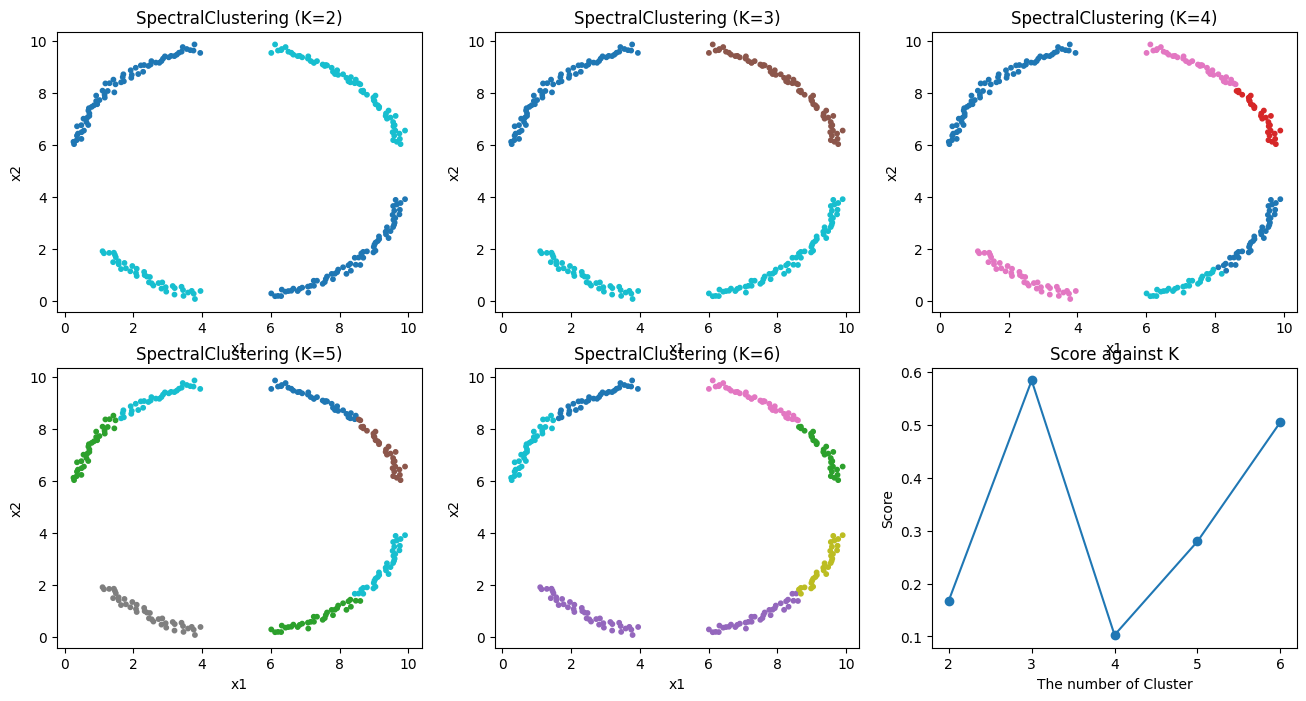

In [9]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

datasets2 = 'lab03_dataset_2.csv'
df2 = pd.read_csv(datasets2)
X = df2[['x1', 'x2']].values

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
scores = []

# spectral clustering
for i, k in enumerate(range(2, 7)):
    # clustering
    spectral = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
    labels = spectral.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    
    r = i // 3
    c = i % 3
    axes[r, c].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=10)
    axes[r, c].set_title(f"SpectralClustering (K={k})")
    axes[r, c].set_xlabel("x1")
    axes[r, c].set_ylabel("x2")

axes[1, 2].plot(range(2, 7), scores, marker='o')
axes[1, 2].set_title("Score against K")
axes[1, 2].set_xlabel("The number of Cluster")
axes[1, 2].set_ylabel("Score")


plt.show()



### 2.b (6 marks)

Repeat `2.a` but instead use sklearn's `AgglomerativeClustering` model for learning.

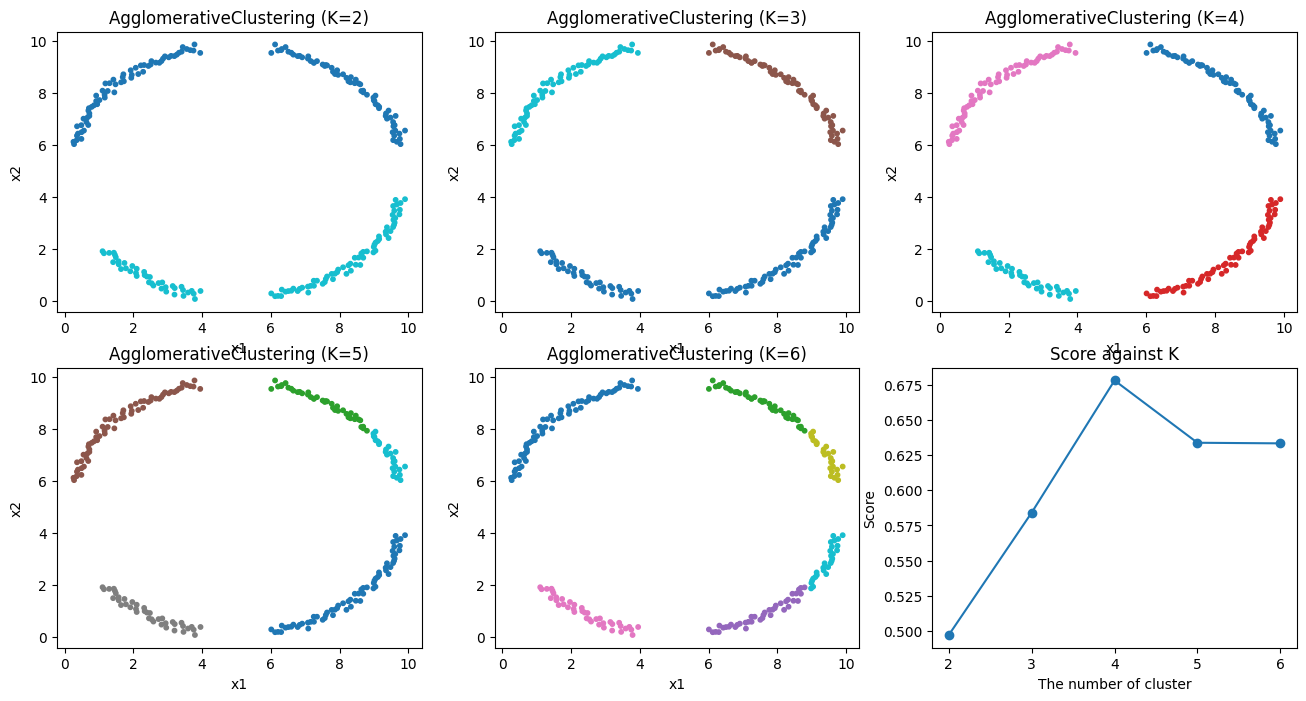

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

datasets2 = 'lab03_dataset_2.csv'
df2 = pd.read_csv(datasets2)
X = df2[['x1', 'x2']].values


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
scores = []

# agglomerative clustering
for i, k in enumerate(range(2, 7)):
    agglomerative = AgglomerativeClustering(n_clusters=k)
    labels = agglomerative.fit_predict(X)
    
    score = silhouette_score(X, labels)
    scores.append(score)
    
    row = i // 3
    col = i % 3
    axes[row, col].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=10)
    axes[row, col].set_title(f"AgglomerativeClustering (K={k})")
    axes[row, col].set_xlabel("x1")
    axes[row, col].set_ylabel("x2")

axes[1, 2].plot(range(2, 7), scores, marker='o')
axes[1, 2].set_title("Score against K")
axes[1, 2].set_xlabel("The number of cluster")
axes[1, 2].set_ylabel("Score")


plt.show()


### 2.c (6 marks)

Using `lab03_dataset_3.csv`, apply sklearn's `GaussianMixture` on the two-dimensional data and output the resulting clusters using a scatterplot. You will apply `GaussianMixture` over several clusters ranging from cluster-count `K = 2 to 6`. Make sure your scatterplot uses `K colors` to clearly distinguish the data points belonging in their respective `K clusters`. Also, compute the `Silhouette score` for each of those `K clusters` and plot the `Silhouette score` against `K clusters`. Label the plot axes accordingly.

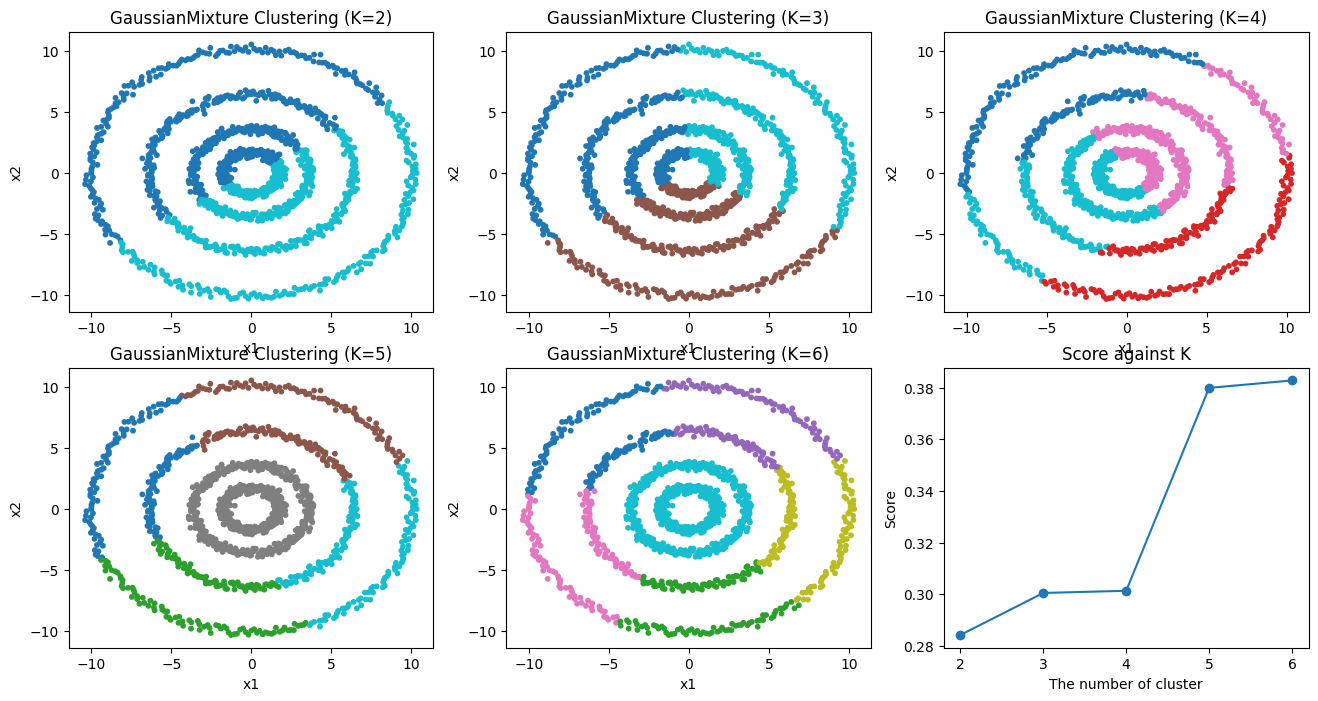

In [11]:
from sklearn.mixture import GaussianMixture

datasets3 = 'lab03_dataset_3.csv'
df3 = pd.read_csv(datasets3)
X = df3[['x1', 'x2']].values


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
scores = []

# gaussian mixture
for i, k in enumerate(range(2, 7)):
    gm = GaussianMixture(n_components=k, random_state=42)
    gm.fit(X)
    labels = gm.predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    
    row = i // 3
    col = i % 3
    axes[row, col].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=10)
    axes[row, col].set_title(f"GaussianMixture Clustering (K={k})")
    axes[row, col].set_xlabel("x1")
    axes[row, col].set_ylabel("x2")

axes[1, 2].plot(range(2, 7), scores, marker='o')
axes[1, 2].set_title("Score against K")
axes[1, 2].set_xlabel("The number of cluster")
axes[1, 2].set_ylabel("Score")


plt.show()


### 2.d (6 marks)

Repeat `2.c` but instead use sklearn's `KMeans` model for learning.

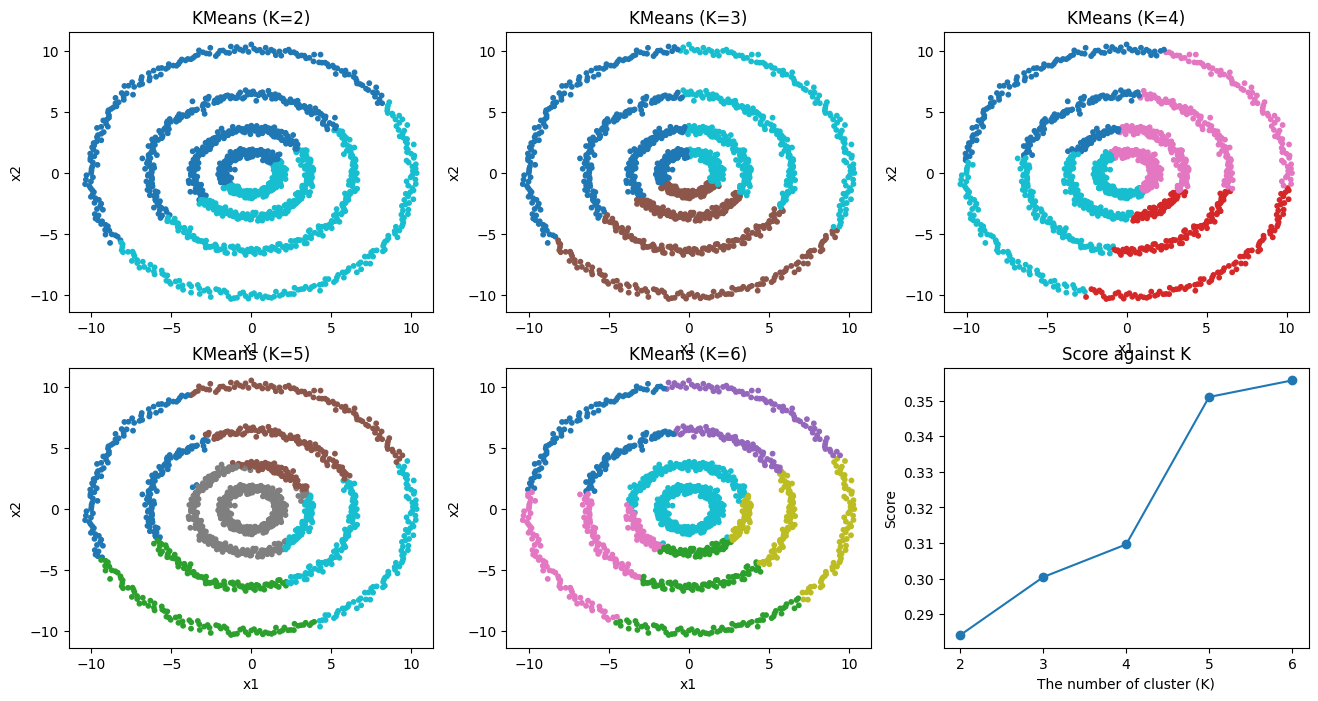

In [12]:
from sklearn.cluster import KMeans

datasets3 = 'lab03_dataset_3.csv'
df3 = pd.read_csv(datasets3)
X = df3[['x1', 'x2']].values

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
scores = []

# KMeans
for i, k in enumerate(range(2, 7)):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    
    row = i // 3
    col = i % 3
    axes[row, col].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=10)
    axes[row, col].set_title(f"KMeans (K={k})")
    axes[row, col].set_xlabel("x1")
    axes[row, col].set_ylabel("x2")

axes[1, 2].plot(range(2, 7), scores, marker='o')
axes[1, 2].set_title("Score against K")
axes[1, 2].set_xlabel("The number of cluster (K)")
axes[1, 2].set_ylabel("Score")


plt.show()


### 2.e (6 marks)

The dataset `lab03_dataset_3.csv` generates 4 concentric rings, so ideally we would want 4 clusters representing the 4 concentric rings. Did the clustering attempts in `3.c` and `3.d` lead to 4 concentric ring clusters? Explore some other sklearn clustering algorithms to see which one can actually produce 4 clusters corresponding with the 4 concentric rings and display it.

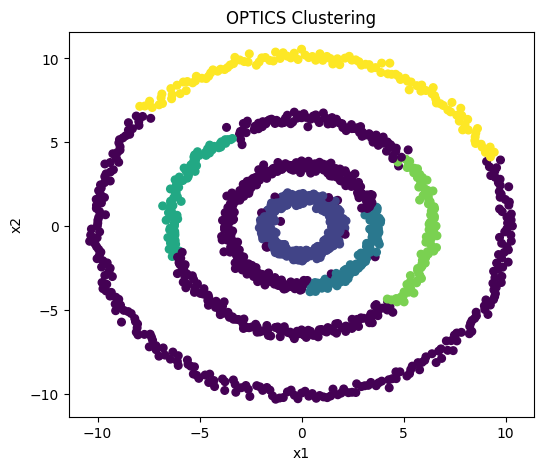

In [13]:
from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(X)
labels_optics = optics.labels_

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_optics, cmap='viridis', s=30)
plt.title('OPTICS Clustering')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### Problem 3: MLP Classification (25 marks)

Using `lab03_dataset_4.csv`, train a MLP classifier with sklearn's `MLPClassifier`. The inputs are *alcohol, citric_acid, free_sulfur_dioxide, residual_sugar, sulphates* and the output is *quality_grp*, which has two categories, 0 and 1.

### 3.a (15 marks)

1. Normalize the input features.
2. Use a train-test split of 80-20.
3. For the learning task, you will train neural network models with different architectures:
   <br>Activation function = [logistic, relu, tanh]
   <br>Hidden layers = [1, 2, 3, 4, 5]
   <br>Neurons per layer = [2, 4, 6, 8]

So, in the first iteration you will create a learning model using the neural network architecture `[logistic, 1, 2]`, in the second iteration you will use `[logistic, 1, 4]`, all the way to `[tanh, 5, 8]`. For each of these learned models, compute the `misclassification rate` on the test set. Once you are done with all the training, you should generate a DataFrame with columns `Activation function, Hidden layers, Neurons per layer, Misclassification rate`, where each row will correspond with the individual training models. Since the total count of `activation functions, hidden layers, neurons` are `3, 5, 4` respectively, the `number of rows` in your output DataFrame should be `3 x 5 x 4 = 60`.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

datasets4 = 'lab03_dataset_4.csv'
df4 = pd.read_csv(datasets4)

features = ['alcohol', 'citric_acid', 'free_sulfur_dioxide', 'residual_sugar', 'sulphates']
target = 'quality_grp'
X = df4[features]
y = df4[target]




In [15]:
# Normalize the input features.
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Use a train-test split of 80-20.
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)



In [16]:
# Train neural network models with different architectures:
activations = ['logistic', 'relu', 'tanh']
hidden_layers = [1, 2, 3, 4, 5]
neurons = [2, 4, 6, 8]

output = []
for a in activations:
    for h in hidden_layers:
        for n in neurons:
            hidden_structure = tuple([n] * h) 
            
            # Train model
            mlpc = MLPClassifier(hidden_layer_sizes=hidden_structure, activation=a, max_iter=500, random_state=42)
            mlpc.fit(X_train, y_train)
            y_pred = mlpc.predict(X_test)
            misclass_rate = 1 - accuracy_score(y_test, y_pred)
            
            # Save result
            output.append({
                'Activation function': a,
                'Hidden layers': h,
                'Neurons per layer': n,
                'Misclassification rate': misclass_rate
            })

results_df = pd.DataFrame(output)
results_df

,Activation function,Hidden layers,Neurons per layer,Misclassification rate
0,logistic,1,2,0.191538
1,logistic,1,4,0.188462
2,logistic,1,6,0.189231
3,logistic,1,8,0.191538
4,logistic,2,2,0.212308
5,logistic,2,4,0.212308
6,logistic,2,6,0.191538
7,logistic,2,8,0.193077
8,logistic,3,2,0.212308
9,logistic,3,4,0.193077


### 3.b (5 marks)

The model with the `lowest misclassification rate` is the `best neural network`. Output the model parameters (activation function, hidden layers, neurons) of the `best neural network`. In the case of ties, choose the network with fewer neurons overall.

In [17]:

results_df['Total neurons'] = results_df['Hidden layers'] * results_df['Neurons per layer']

sorted_df = results_df.sort_values(by=['Misclassification rate'])

best = sorted_df.iloc[0]

print("Best Neural Network:")
print(f"\nActivation Function: {best['Activation function']}")
print(f"Hidden Layers: {best['Hidden layers']}")
print(f"Neurons per Layer: {best['Neurons per layer']}")
print(f"Misclassification Rate: {best['Misclassification rate']:.4f}")


Best Neural Network:

Activation Function: tanh
Hidden Layers: 3
Neurons per Layer: 8
Misclassification Rate: 0.1785


### 3.c (5 marks)

Create a scatterplot of the `misclassification rates vs activation functions`. The scatterplot should have 3 colors differentiating the misclassification rates associated with the 3 activation functions.

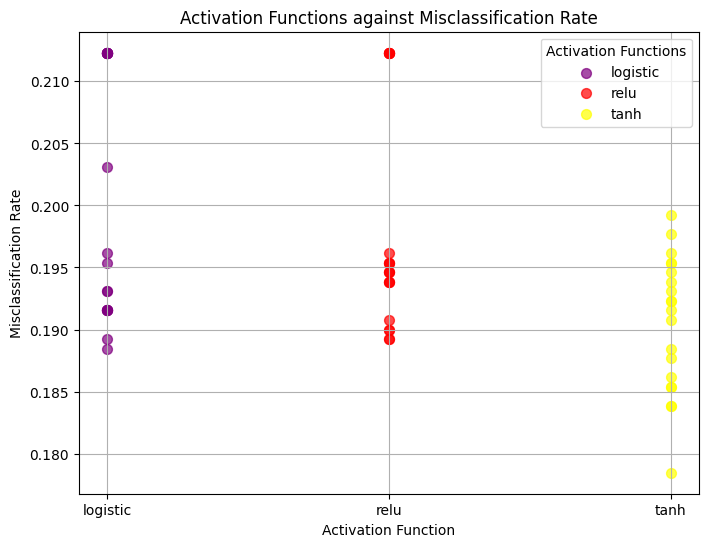

In [18]:


colors = {'logistic': 'purple', 'relu': 'red', 'tanh': 'yellow'}

plt.figure(figsize=(8,6))

for a in results_df['Activation function'].unique():
    subset = results_df[results_df['Activation function'] == a]
    plt.scatter([a] * len(subset), subset['Misclassification rate'], color=colors[a], label=a, s=50, alpha=0.7)

plt.xlabel('Activation Function')
plt.ylabel('Misclassification Rate')
plt.title('Activation Functions against Misclassification Rate')
plt.legend(title='Activation Functions')
plt.grid(True)
plt.show()


### Problem 4: MLP Regression (25 marks)

Using `lab03_dataset_5.csv`, train a MLP classifier with sklearn's `MLPRegressor`. The inputs are *housing_median_age, total_rooms, households, median_income* and the output is *median_house_value*.

### 4.a (15 marks)

1. Normalize the entire dataset.
2. Use a train-test split of 80-20.
3. For the learning task, you will train neural network models with different architectures:
   <br>Activation function = [logistic, relu, tanh]
   <br>Hidden layers = [1, 2, 3, 4, 5]
   <br>Neurons per layer = [2, 4, 6, 8]

So, in the first iteration you will create a learning model using the neural network architecture `[logistic, 1, 2]`, in the second iteration you will use `[logistic, 1, 4]`, all the way to `[tanh, 5, 8]`. For each of these learned models, compute the `root mean squared error` on the test set. Once you are done with all the training, you should generate a DataFrame with columns `Activation function, Hidden layers, Neurons per layer, Root mean squared error`, where each row will correspond with the individual training models. Since the total count of `activation functions, hidden layers, neurons` are `3, 5, 4` respectively, the `number of rows` in your output DataFrame should be `3 x 5 x 4 = 60`.

In [19]:
datasets5 = 'lab03_dataset_5.csv'
df5 = pd.read_csv(datasets5)

features = ['housing_median_age', 'total_rooms', 'households', 'median_income']
target = 'median_house_value'
X = df5[features]
y = df5[target]

In [20]:
# Normalize the entire dataset.
scaler = StandardScaler()
X_normalized_2 = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_normalized_2, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
activations = ['logistic', 'relu', 'tanh']
hidden_layers = [1, 2, 3, 4, 5]
neurons = [2, 4, 6, 8]


output = []

for a in activations:
    for h in hidden_layers:
        for n in neurons:
            # Create hidden layer structure (e.g., (6, 6, 6) for 3 layers of 6 neurons)
            hidden_structure = tuple([n] * h)
            
            # Train model
            reg = MLPRegressor(hidden_layer_sizes=hidden_structure,
                               activation=a,
                               max_iter=500,
                               random_state=42)
            reg.fit(X_train, y_train)
            
            y_pred = reg.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            output.append({
                'Activation function': a,
                'Hidden layers': h,
                'Neurons per layer': n,
                'Root mean squared error': rmse
            })


results_df = pd.DataFrame(output)
results_df

/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/miumiu/Downloads/2025-CS584_MachineLearning/Assignment_1/virtual/lib/python3.10/site-packages/sklearn/neural_network/_multi

,Activation function,Hidden layers,Neurons per layer,Root mean squared error
0,logistic,1,2,240204.713010
1,logistic,1,4,240145.605753
2,logistic,1,6,240084.607646
3,logistic,1,8,240025.549627
4,logistic,2,2,240205.510354
5,logistic,2,4,240145.993081
6,logistic,2,6,240085.851981
7,logistic,2,8,240024.869503
8,logistic,3,2,240205.623446
9,logistic,3,4,240145.830736


### 4.b (5 marks)

The model with the `lowest RMSE` is the `best neural network`. Output the model parameters (activation function, hidden layers, neurons) of the `best neural network`. In the case of ties, choose the network with fewer neurons overall.

In [24]:

best2 = results_df.sort_values(by=['Root mean squared error']).iloc[0]


print("Best Neural Network:")
print(f"Activation Function: {best2['Activation function']}")
print(f"Hidden Layers: {best2['Hidden layers']}")
print(f"Neurons per Layer: {best2['Neurons per layer']}")
print(f"Root Mean Squared Error: {best2['Root mean squared error']:.4f}")


Best Neural Network:
Activation Function: relu
Hidden Layers: 5
Neurons per Layer: 8
Root Mean Squared Error: 74117.3704


### 4.c (5 marks)

Create a scatterplot of the `root mean squared error vs activation functions`. The scatterplot should have 3 colors differentiating the misclassification rates associated with the 3 activation functions.

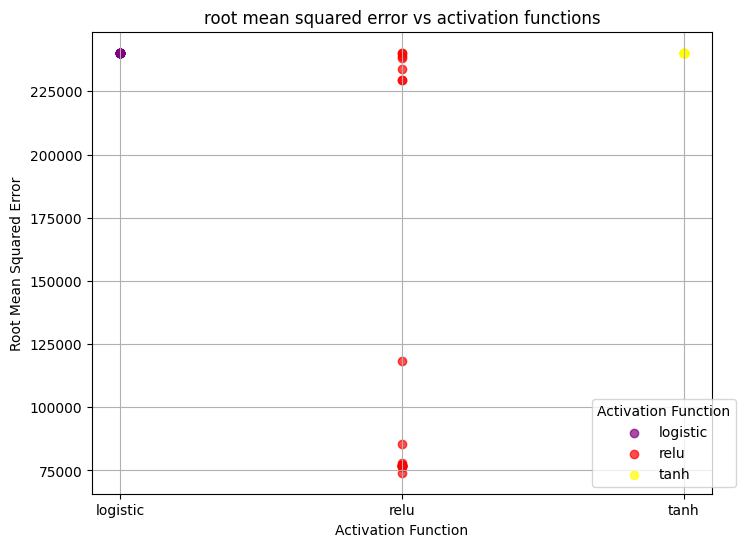

In [27]:

colors = {
    'logistic': 'purple',
    'relu': 'red',
    'tanh': 'yellow'
}

plt.figure(figsize=(8, 6))

for act_func in results_df['Activation function'].unique():
    subset = results_df[results_df['Activation function'] == act_func]
    plt.scatter(
        [act_func] * len(subset),
        subset['Root mean squared error'],
        color=colors[act_func],
        label=act_func,
        alpha=0.7
    )

plt.title("root mean squared error vs activation functions")
plt.xlabel("Activation Function")
plt.ylabel("Root Mean Squared Error")
plt.grid(True)
plt.legend(title="Activation Function", loc='lower right', bbox_to_anchor=(1.05, 0))
plt.show()
